In [ ]:
#修改模型保存路径2个，
#修改数据读取文件
#记录字典
#记录模型的准确率
#记录特征值排序和图片
#批量预测AO1065chemicals

In [ ]:
#特征 = Morgan指纹 + Mordred描述符

In [1]:
# ======================================
# 1. 导入依赖库
# ======================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE  # 数据平衡
import rdkit
from rdkit.Chem import AllChem
from rdkit import Chem
import warnings
import os
import shap
import matplotlib.pyplot as plt  # SHAP可视化
warnings.filterwarnings("ignore")

from mordred import Calculator, descriptors
from rdkit.Chem import MolFromSmiles

# 设置随机种子（保证结果可复现）
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ======================================

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
# 2. 数据预处理工具函数
# ======================================
def get_morgan_fingerprint(smiles, n_bits=1024):
    """将SMILES转换为1024维Morgan指纹（ECFP4）"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # 处理无效SMILES
        return np.zeros(n_bits)
    # radius=2对应ECFP4，是毒理预测的标准参数
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    return np.array(fp)

# 修正：动态计算毒理相关描述符（不硬编码维度）
def get_toxicity_descriptors(smiles):
    """计算2D毒理相关描述符（动态返回维度，不固定208）"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # 先计算一次有效SMILES的描述符维度，再返回全0数组（后续统一）
        # 临时计算有效SMILES的描述符维度
        temp_mol = Chem.MolFromSmiles("C1=CC=CC=C1")  # 用苯作为参考SMILES
        temp_calc = Calculator(descriptors, ignore_3D=True)
        temp_desc = temp_calc(temp_mol)
        temp_desc = temp_desc.fill_missing(0)
        desc_dim = len(np.array(temp_desc))
        return np.zeros(desc_dim, dtype=np.float32)
    
    # 仅计算2D描述符（忽略3D，避免维度爆炸）
    calc = Calculator(descriptors, ignore_3D=True)
    desc = calc(mol)
    
    # 处理缺失值/无穷值（关键）
    desc = desc.fill_missing(0)  # 缺失值填充0
    desc_array = np.array(desc)
    desc_array[np.isinf(desc_array)] = 0  # 无穷值替换为0
    desc_array = desc_array.astype(np.float32)
    
    return desc_array

# 新增：获取描述符的真实维度（全局唯一）
def get_descriptor_dim(smiles_list):
    """从有效SMILES中获取描述符的真实维度"""
    # 找第一个有效SMILES
    valid_smiles = None
    for smiles in smiles_list:
        if Chem.MolFromSmiles(smiles) is not None:
            valid_smiles = smiles
            break
    if valid_smiles is None:
        raise ValueError("无有效SMILES，无法计算描述符维度")
    
    # 计算该SMILES的描述符维度
    desc = get_toxicity_descriptors(valid_smiles)
    return len(desc)

def map_species_to_id(species_list):
    """将物种类别映射为数字ID（用于Embedding层）"""
    unique_species = sorted(list(set(species_list)))
    species2id = {s: i for i, s in enumerate(unique_species)}
    id2species = {i: s for s, i in species2id.items()}
    #将物种ID从列表转为NumPy数组
    species_ids = np.array([species2id[s] for s in species_list])
    return species_ids, species2id, id2species

# ======================================

In [3]:
# 3. 自定义数据集类
# ======================================
class ToxicityDataset(Dataset):
    def __init__(self, compound_features, species_ids, labels):
        # ⭐compound_features = Morgan指纹 + 理化性质
        self.compound_features = torch.tensor(compound_features, dtype=torch.float32)
        self.species_ids = torch.tensor(species_ids, dtype=torch.long)  # Embedding需要long型
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)  # 适配BCELoss的维度

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.compound_features[idx],
            self.species_ids[idx],
            self.labels[idx]
        )

# ======================================

In [4]:
# 4. 定义MLP模型
# ======================================
class ReproductiveToxicityMLP(nn.Module):
    def __init__(self, compound_dim, n_species=10, species_emb_dim=16, hidden_dims=[256, 128, 64]):
        super().__init__()
        # 1. 物种Embedding层（将类别特征转为低维向量）
        self.species_emb = nn.Embedding(num_embeddings=n_species, embedding_dim=species_emb_dim)
        
        # 2. 计算输入层总维度：
        # compound_dim (1024+208) + species_emb_dim
        input_dim = compound_dim + species_emb_dim
        
        # 3. 构建MLP隐藏层
        layers = []
        prev_dim = input_dim
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(nn.LeakyReLU(0.1))  # 激活函数，避免梯度消失
            layers.append(nn.Dropout(0.4))  # Dropout防止过拟合
            prev_dim = dim
        
        # 4. 输出层（Sigmoid激活，输出0~1概率）
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        # 组合所有层
        self.mlp = nn.Sequential(*layers)

    def forward(self, compound_feat, species_id):
        # 物种ID转Embedding
        species_emb = self.species_emb(species_id)  # [batch, species_emb_dim]
        # 拼接所有特征：化合物特征 + 物种Embedding 
        x = torch.cat([compound_feat, species_emb], dim=1)
        # MLP前向传播
        output = self.mlp(x)
        return output

# ======================================

In [5]:
# 5. 训练与评估函数
# ======================================
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, device="cpu"):
    """训练模型并验证"""
    model.to(device)
    best_val_auc = 0.0  # 保存最优验证集AUC
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        train_loss = 0.0
        for comp_feat, species_ids, labels in train_loader:
            # 数据移到设备（CPU/GPU）
            comp_feat, species_ids, labels = comp_feat.to(device), species_ids.to(device), labels.to(device)
            
            # 前向传播
            outputs = model(comp_feat, species_ids)
            loss = criterion(outputs, labels)
            
            # 反向传播+优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * comp_feat.size(0)
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_labels = []
        with torch.no_grad():  # 关闭梯度计算
            for comp_feat, species_ids, labels in val_loader:
                comp_feat, species_ids, labels = comp_feat.to(device), species_ids.to(device), labels.to(device)
                outputs = model(comp_feat, species_ids)
                
                val_loss += criterion(outputs, labels).item() * comp_feat.size(0)
                val_preds.extend(outputs.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
        
        # 计算平均损失和AUC
        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_auc = roc_auc_score(val_labels, val_preds)
        
        # 保存最优模型
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), "model_KE1076.pth")
        
        # 打印日志
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUC: {val_auc:.4f}")
    
    # 加载最优模型
    model.load_state_dict(torch.load("model_KE1076.pth"))
    return model

def evaluate_model(model, test_loader, device="cpu"):
    """评估模型性能（AUC、准确率、分类报告）"""
    model.to(device)
    model.eval()
    test_preds = []
    test_labels = []
    
    with torch.no_grad():
        for comp_feat, species_ids, labels in test_loader:
            comp_feat, species_ids, labels = comp_feat.to(device), species_ids.to(device), labels.to(device)
            outputs = model(comp_feat, species_ids)
            
            test_preds.extend(outputs.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())
    
    # 转换为数组
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)
    
    # 计算指标
    test_auc = roc_auc_score(test_labels, test_preds)
    
    # 以0.5为阈值判定类别
    test_pred_classes = (test_preds >= 0.5).astype(int)
    test_acc = accuracy_score(test_labels, test_pred_classes)
    
    print("\n===== 模型评估结果 =====")
    print(f"Test AUC: {test_auc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("\n分类报告：")
    print(classification_report(test_labels, test_pred_classes, target_names=["无毒", "有毒"]))
    
    return test_auc, test_acc

def predict_toxicity(
    model, 
    smiles, 
    species, 
    species2id, 
    device="cpu"
):
    """
    单样本预测：输入SMILES、物种、浓度，输出毒性概率
    参数说明：
    - model: 训练好的模型
    - smiles: 化合物SMILES字符串
    - species: 物种名称（如"大鼠"）
    - species2id: 物种映射字典（训练时生成的species2id）
    - device: 运行设备（"cpu"/"cuda"）
    返回：
    - prob: 毒性概率（0~1）
    """
    # -------------------------- 1. 输入合法性校验（新增） --------------------------
    if not isinstance(smiles, str) or len(smiles) == 0:
        raise ValueError("SMILES必须是非空字符串")
    if not isinstance(species, str) or len(species) == 0:
        raise ValueError("物种名称必须是非空字符串")
    
    # -------------------------- 2. 模型准备 --------------------------
    model.to(device)
    model.eval()  # 评估模式，关闭Dropout/BatchNorm
    
    # -------------------------- 3. 化合物特征处理（与训练一致） --------------------------
    fp = get_morgan_fingerprint(smiles)
    desc = get_toxicity_descriptors(smiles)
    compound_feat = np.hstack([fp, desc])  
    # 增加batch维度 + 转tensor + 移到指定设备
    compound_feat = torch.tensor(compound_feat, dtype=torch.float32).unsqueeze(0).to(device)
    
    # -------------------------- 4. 物种ID处理（修复默认值） --------------------------
    # 未知物种映射为-1，再转为0（避免覆盖真实物种ID）
    species_id = species2id.get(species, -1)
    if species_id == -1:
        print(f"警告：未知物种{species}，使用默认ID=0")
        species_id = 0
    species_id = torch.tensor([species_id], dtype=torch.long).to(device)
    
    
    # -------------------------- 5. 模型预测 --------------------------
    with torch.no_grad():  # 禁用梯度计算，节省内存
        # 模型前向传播
        prob = model(compound_feat, species_id)
        # 转为numpy + 去除batch维度
        prob = prob.cpu().numpy()[0][0]
    
    # -------------------------- 7. 输出校验（新增） --------------------------
    prob = max(0.0, min(1.0, prob))  # 确保概率在0~1之间
    
    return prob

# ======================================

In [6]:
# 6. 数据增强（针对所有正负样本）
# ======================================
import os
import requests
import pandas as pd
import csv
from SmilesEnumerator import SmilesEnumerator
sme = SmilesEnumerator()
print(help(SmilesEnumerator))
import pandas as pd
# 注意：需要确认sme库的正确导入（通常是selfies或rdkit的随机化工具）
# 如果是rdkit的随机化，替换为：from rdkit.Chem import MolFromSmiles, MolToSmiles
import random

# ====================== 1. 读取原始数据 ======================
# 读取包含smiles、activity、species的原始Excel
drug = pd.read_excel("KE1076.xlsx")  #物种名称尾部是否有空格，因为空格也会被识别为字符串。

# 提取原始列（确保Excel中有这四列：smiles、activity、species）
list_smiles = drug['smiles'].tolist()       # SMILES列表
list_toxicity = drug['toxicity'].tolist()   # 活性值列表
list_species = drug['species'].tolist()      # 暴露物种列表

# ====================== 2. 定义SMILES随机化函数（兼容rdkit） ======================
# 如果你用的是sme库，保留这行；如果是rdkit，注释掉并启用下面的函数
# import sme  # 确保sme库已安装

def randomize_smiles(smiles):
    """SMILES随机化（兼容sme/rdkit，防止报错）"""
    try:
        # 方式1：使用sme库（你的原始逻辑）
        response = sme.randomize_smiles(smiles)
        return response
    except:
        # 方式2：备用（rdkit实现SMILES随机化）
        from rdkit.Chem import MolFromSmiles, MolToSmiles
        mol = MolFromSmiles(smiles)
        if mol is None:
            return smiles  # 无效SMILES直接返回原值
        return MolToSmiles(mol, doRandom=True)

# ====================== 3. 批量重复+随机化 ======================
# 初始化空列表存储重复后的数据
smi = []       # 随机化后的SMILES（每个原始SMILES生成10个）
tox = []       # 重复的活性值（每个值重复10次）
species = []   # 重复的暴露物种（每个值重复10次）

# 遍历原始数据的每一行（按索引同步遍历四列）
for idx in range(len(list_smiles)):
    original_smiles = list_smiles[idx]
    original_toxicity = list_toxicity[idx]
    original_species = list_species[idx]
    
    # 每个化合物生成10个随机SMILES，同时重复物种/活性值
    for i in range(10):
        # 生成随机化SMILES并添加
        random_smi = randomize_smiles(original_smiles)
        smi.append(random_smi)
        
        # 重复添加对应的活性、物种（保持一一对应）
        tox.append(original_toxicity)
        species.append(original_species)

# ====================== 4. 构建DataFrame并保存 ======================
# 构建DataFrame（四列：smiles、activity、species）
df = pd.DataFrame({
    'smiles': smi,
    'toxicity': tox,
    'species': species
})

# 保存到Excel（index=False避免多余的索引列）
df.to_excel("aolistnumber.xlsx", index=False)

print(f"数据生成完成！原始数据行数：{len(drug)}，生成后行数：{len(df)}")
print("前5行数据预览：")
print(df.head())

Help on class SmilesEnumerator in module SmilesEnumerator:

class SmilesEnumerator(builtins.object)
 |  SmilesEnumerator(charset='@C)(=cOn1S2/H[N]\\', pad=120, leftpad=True, isomericSmiles=True, enum=True, canonical=False)
 |  
 |  SMILES Enumerator, vectorizer and devectorizer
 |  
 |  #Arguments
 |      charset: string containing the characters for the vectorization
 |        can also be generated via the .fit() method
 |      pad: Length of the vectorization
 |      leftpad: Add spaces to the left of the SMILES
 |      isomericSmiles: Generate SMILES containing information about stereogenic centers
 |      enum: Enumerate the SMILES during transform
 |      canonical: use canonical SMILES during transform (overrides enum)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, charset='@C)(=cOn1S2/H[N]\\', pad=120, leftpad=True, isomericSmiles=True, enum=True, canonical=False)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  fit(self, smiles, extra_char

In [8]:
# 6. 数据增强（仅针对正或负样本——当数据严重不平衡时）
import os
import requests
import pandas as pd
import csv
from SmilesEnumerator import SmilesEnumerator
sme = SmilesEnumerator()
import random

# ====================== 1. 读取原始数据 ======================
# 读取包含smiles、activity、species的原始Excel
drug = pd.read_excel("KE1076.xlsx")  # 注意物种名称尾部空格问题

# 提取原始列（确保Excel中有这四列：smiles、toxicity、species）
list_smiles = drug['smiles'].tolist()       # SMILES列表
list_toxicity = drug['toxicity'].tolist()   # 活性值列表（1=活性，其他=非活性）
list_species = drug['species'].tolist()      # 暴露物种列表

# ====================== 2. 定义SMILES随机化函数（兼容rdkit） ======================
def randomize_smiles(smiles):
    """SMILES随机化（兼容sme/rdkit，防止报错）"""
    try:
        # 方式1：使用sme库
        response = sme.randomize_smiles(smiles)
        return response
    except:
        # 方式2：备用（rdkit实现SMILES随机化）
        from rdkit.Chem import MolFromSmiles, MolToSmiles
        mol = MolFromSmiles(smiles)
        if mol is None:
            return smiles  # 无效SMILES直接返回原值
        return MolToSmiles(mol, doRandom=True)

# ====================== 3. 差异化增强：仅增强toxicity=1的样本 ======================
# 初始化空列表存储最终数据
smi = []       # 最终SMILES列表
tox = []       # 最终活性值列表
species = []   # 最终暴露物种列表

# 定义增强倍数（每个活性样本生成10个随机SMILES）
augment_times = 10

# 遍历原始数据的每一行
for idx in range(len(list_smiles)):
    original_smiles = list_smiles[idx]
    original_toxicity = list_toxicity[idx]
    original_species = list_species[idx]
    
    # 仅对toxicity=1的样本进行增强
    if original_toxicity == 1:
        # 活性样本：生成augment_times个随机SMILES，重复对应标签/特征
        for i in range(augment_times):
            random_smi = randomize_smiles(original_smiles)
            smi.append(random_smi)
            tox.append(original_toxicity)
            species.append(original_species)
    else:
        # 非活性样本：仅保留原始数据，不增强
        smi.append(original_smiles)
        tox.append(original_toxicity)
        species.append(original_species)

# ====================== 4. 构建DataFrame并保存 ======================
df = pd.DataFrame({
    'smiles': smi,
    'toxicity': tox,
    'species': species
})

# 保存到Excel（index=False避免多余的索引列）
df.to_excel("aolistnumber.xlsx", index=False)

# 打印数据增强统计信息
original_active = sum(1 for t in list_toxicity if t == 1)
original_inactive = len(list_toxicity) - original_active
final_active = sum(1 for t in tox if t == 1)
final_inactive = len(tox) - final_active

print(f"数据生成完成！")
print(f"原始数据：活性样本{original_active}个，非活性样本{original_inactive}个，总计{len(list_toxicity)}个")
print(f"增强后：活性样本{final_active}个，非活性样本{final_inactive}个，总计{len(df)}个")
print("\n前5行数据预览：")
print(df.head())

数据生成完成！
原始数据：活性样本120个，非活性样本90个，总计210个
增强后：活性样本1200个，非活性样本90个，总计1290个

前5行数据预览：
                                 smiles  toxicity species
0  C[C@]12CC[C@H]3C@@H[C@@H]1CC[C@@H]2O         1  Mouse 
1  C[C@]12CC[C@H]3C@@H[C@@H]1CC[C@@H]2O         1  Mouse 
2  C[C@]12CC[C@H]3C@@H[C@@H]1CC[C@@H]2O         1  Mouse 
3  C[C@]12CC[C@H]3C@@H[C@@H]1CC[C@@H]2O         1  Mouse 
4  C[C@]12CC[C@H]3C@@H[C@@H]1CC[C@@H]2O         1  Mouse 


In [7]:
# 7. SHAP特征重要性分析（核心新增）
# ======================================
def shap_analysis_wrapper(model, compound_features, species_ids, species2id, device="cpu"):
    """
    最终修复版SHAP分析：适配DeepExplainer，解决tuple.detach()报错
    核心：将双输入合并为单Tensor输入，内部拆分使用
    """
    # 设置中文字体（解决可视化中文乱码）
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    
    # -------------------------- 步骤1：重构模型（单Tensor输入） --------------------------
    class SHAPCompatibleModel(nn.Module):
        def __init__(self, original_model, compound_dim):
            super().__init__()
            self.original_model = original_model
            self.compound_dim = compound_dim  # 化合物特征维度（用于拆分）
        
        def forward(self, combined_input):
            """
            单Tensor输入：前compound_dim维是化合物特征，最后1维是物种ID（long型）
            """
            # 拆分输入：化合物特征（float） + 物种ID（long）
            compound_feat = combined_input[:, :self.compound_dim].float()
            species_id = combined_input[:, self.compound_dim:].long().squeeze(1)  # 转为一维long型
            
            # 调用原模型前向传播
            return self.original_model(compound_feat, species_id)
    
    # 初始化适配模型
    compound_dim = compound_features.shape[1]
    shap_model = SHAPCompatibleModel(model, compound_dim).to(device)
    shap_model.eval()
    
    # -------------------------- 步骤2：合并输入为单Tensor（关键修复） --------------------------
    # 物种ID转为2D Tensor（与化合物特征维度匹配）
    species_ids_2d = np.expand_dims(species_ids, axis=1)  # [n_samples, 1]
    # 合并化合物特征（float）和物种ID（float，内部再转long）
    combined_input = np.hstack([compound_features, species_ids_2d]).astype(np.float32)
    # 转为PyTorch Tensor
    combined_tensor = torch.tensor(combined_input, dtype=torch.float32).to(device)
    
    # -------------------------- 步骤3：采样减少计算量（高维特征必做） --------------------------
    # 背景数据采样（DeepExplainer的基准数据，50个样本足够）
    background_size = min(50, len(combined_tensor))
    background_data = combined_tensor[:background_size].detach()  # 手动detach避免梯度问题
    
    # 分析数据采样（控制在200个样本内，平衡速度和精度）
    shap_sample_size = min(200, len(combined_tensor))
    sample_idx = np.random.choice(len(combined_tensor), shap_sample_size, replace=False)
    sample_data = combined_tensor[sample_idx].detach()
    
    # -------------------------- 步骤4：初始化DeepExplainer（纯PyTorch，无TF依赖） --------------------------
    explainer = shap.DeepExplainer(
        model=shap_model,
        data=background_data
    )
    
    # -------------------------- 步骤5：计算SHAP值（核心） --------------------------
    shap_values = explainer.shap_values(sample_data)
    # 处理SHAP值格式（确保是2D数组）
    shap_values_np = np.array(shap_values).squeeze()
    if len(shap_values_np.shape) == 1:
        shap_values_np = shap_values_np.reshape(1, -1)
    
    # 提取采样数据的numpy格式（用于可视化）
    sample_data_np = sample_data.cpu().numpy()
    
    # -------------------------- 步骤6：生成特征名称（含物种ID映射） --------------------------
    # 1. Morgan指纹特征名（1024维）
    fp_names = [f"Morgan_FP_{i}" for i in range(1024)]
    # 2. 毒理描述符特征名（动态维度）
    desc_dim = compound_dim - 1024
    desc_names = [f"Toxic_Descriptor_{i}" for i in range(desc_dim)]
    # 3. 物种ID特征名（单独1维）
    species_names = ["Species_ID"]
    # 合并所有特征名
    feature_names = fp_names + desc_names + species_names
    
    # -------------------------- 步骤7：可视化SHAP结果 --------------------------
    # 7.1 全局特征重要性条形图（前20）
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_np,
        features=sample_data_np,
        feature_names=feature_names,
        plot_type="bar",
        max_display=20,
        show=False
    )
    plt.title("MLP毒理预测 - SHAP全局特征重要性（前20）", fontsize=14)
    plt.tight_layout()
    plt.savefig("shap_global_importance.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 7.2 SHAP摘要图（特征取值与贡献关系）
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_np,
        features=sample_data_np,
        feature_names=feature_names,
        max_display=20,
        show=False
    )
    plt.title("MLP毒理预测 - SHAP特征贡献摘要图（前20）", fontsize=14)
    plt.tight_layout()
    plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # -------------------------- 步骤8：生成特征重要性数值报告 --------------------------
    # 计算每个特征的平均绝对SHAP值（重要性）
    shap_importance = np.abs(shap_values_np).mean(axis=0)
    importance_df = pd.DataFrame({
        "Feature_Name": feature_names,
        "SHAP_Importance": shap_importance
    }).sort_values(by="SHAP_Importance", ascending=False)
    
    # 保存到CSV（便于后续分析）
    importance_df.to_csv("shap_feature_importance.csv", index=False, encoding="utf-8")
    
    # 打印关键结果
    print("\n===== SHAP特征重要性排名（前20） =====")
    print(importance_df.head(20))
    
    # 单独提取物种相关特征的重要性
    species_importance = importance_df[importance_df["Feature_Name"] == "Species_ID"]
    print("\n===== 物种特征重要性 =====")
    print(species_importance)
    
    # 补充：物种ID与名称的映射说明
    print("\n===== 物种ID-名称映射 =====")
    for idx, name in species2id.items():
        print(f"ID {idx} -> {name}")
    
    return importance_df

In [8]:
# 8. 主流程（数据准备+训练+评估+预测）
# ======================================
if __name__ == "__main__":
    # ------------------------------
    # 步骤1：从Excel读取真实数据
    # ------------------------------
    excel_path = "aolistnumber.xlsx"
    try:
        data = pd.read_excel(excel_path)
        print(f"✅ 成功读取Excel文件，共{len(data)}条数据")
    except FileNotFoundError:
        raise FileNotFoundError(f"❌ 未找到文件：{excel_path}，请检查文件路径是否正确")
    
    # 关键校验：确保Excel包含所需列
    required_columns = ["smiles", "species", "toxicity"]
    missing_cols = [col for col in required_columns if col not in data.columns]
    if missing_cols:
        raise ValueError(f"❌ Excel文件缺少必要列：{missing_cols}\n请确保列名包含：{required_columns}")
    
    # 数据清洗：去除缺失值
    data = data.dropna(subset=required_columns).reset_index(drop=True)
    print(f"✅ 清洗后有效数据：{len(data)}条")
    
    # 查看毒性标签分布
    print("\n" + "="*60 + " 原始数据毒性标签分布 " + "="*60)
    toxicity_counts = data["toxicity"].value_counts()
    print(toxicity_counts)
    imbalance_ratio = toxicity_counts.max() / toxicity_counts.min()
    print(f"📊 数据不平衡比例：{imbalance_ratio:.2f}")
    
    # ------------------------------
    # 步骤2：数据预处理
    # ------------------------------
    # 1. 获取描述符维度
    desc_dim = get_descriptor_dim(data["smiles"].values)
    print(f"\n📏 Mordred描述符维度：{desc_dim}")
    
    # 2. 生成化合物特征（指纹+描述符）
    print("🔬 正在生成化合物特征...")
    fps = np.array([get_morgan_fingerprint(s) for s in data["smiles"].values])  # 1024维指纹
    descs = np.array([get_toxicity_descriptors(s) for s in data["smiles"].values])  # 描述符
    compound_features = np.hstack([fps, descs])  # 合并特征
    compound_dim = compound_features.shape[1]
    print(f"🔬 化合物特征总维度：{compound_dim}（1024维指纹 + {desc_dim}维描述符）")
    
    # 4. 物种ID映射
    species_ids, species2id, id2species = map_species_to_id(data["species"].values)
    n_species = len(species2id)
    print(f"🔬 物种数量：{n_species}，物种映射表：{species2id}")
    
    # 5. 合并所有特征
    # 将物种ID（类别特征）转为一维数组后合并到特征矩阵
    species_ids_reshaped = species_ids.reshape(-1, 1)  # 转为(n,1)维度
    all_features = np.hstack([compound_features, species_ids_reshaped])
    labels = np.array(data["toxicity"].values)

    # ------------------------------
    # 步骤3：划分数据集 + SMOTE平衡训练集
    # ------------------------------
    # 第一步：划分训练+验证集 vs 测试集（8:2）
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        all_features, labels,
        test_size=0.2, random_state=SEED, stratify=labels
    )
    
    # 第二步：划分训练集 vs 验证集（训练集占整体64%，验证集16%）
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=0.2, random_state=SEED, stratify=y_train_val
    )
    
    # SMOTE过采样平衡训练集（无需依赖sample_indices_）
    print("\n" + "="*60 + " SMOTE过采样平衡训练集 " + "="*60)
    smote = SMOTE(random_state=SEED, k_neighbors=3)  # 小样本适配k=3
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    # 查看平衡结果
    print("⚖️ 平衡前训练集标签分布：")
    print(pd.Series(y_train).value_counts())
    print("⚖️ 平衡后训练集标签分布：")
    print(pd.Series(y_train_balanced).value_counts())
    
    # ------------------------------
    # 步骤4：拆分特征（还原化合物+浓度+物种ID）
    # ------------------------------
    # 特征维度定义：化合物特征 + 浓度特征 + 物种ID
    species_dim = 1  # 物种ID维度（1）
    
    # 拆分平衡后的训练集特征
    compound_train_balanced = X_train_balanced[:, :compound_dim]  # 前compound_dim维：化合物特征
    species_train_balanced = X_train_balanced[:, -species_dim:].reshape(-1).astype(int)  # 最后1维：物种ID
    
    # 拆分验证集特征
    compound_val = X_val[:, :compound_dim]
    species_val = X_val[:, -species_dim:].reshape(-1).astype(int)
    
    # 拆分测试集特征
    compound_test = X_test[:, :compound_dim]
    species_test = X_test[:, -species_dim:].reshape(-1).astype(int)
    
    # ------------------------------
    # 步骤5：构建数据集/数据加载器
    # ------------------------------
    # 构建数据集
    train_dataset = ToxicityDataset(compound_train_balanced, species_train_balanced, y_train_balanced)
    val_dataset = ToxicityDataset(compound_val, species_val, y_val)
    test_dataset = ToxicityDataset(compound_test, species_test, y_test)
    
    # 构建数据加载器
    batch_size = 1  # 可根据平衡后样本数调整（如2/4）
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 输出最终结果
    print("\n" + "="*60 + " 最终数据集信息 " + "="*60)
    print(f"📦 平衡后训练集样本数：{len(train_dataset)}")
    print(f"📦 验证集样本数：{len(val_dataset)}")
    print(f"📦 测试集样本数：{len(test_dataset)}")
    print("\n✅ 数据准备+SMOTE平衡完成，无版本兼容问题！")

✅ 成功读取Excel文件，共210条数据
✅ 清洗后有效数据：210条

============================================================ 原始数据毒性标签分布 ============================================================
toxicity
1    120
0     90
Name: count, dtype: int64
📊 数据不平衡比例：1.33

📏 Mordred描述符维度：1613
🔬 正在生成化合物特征...
🔬 化合物特征总维度：2637（1024维指纹 + 1613维描述符）
🔬 物种数量：5，物种映射表：{'Chicken': 0, 'Homo sapiens': 1, 'Mouse ': 2, 'Rat': 3, 'Vizcacha': 4}

============================================================ SMOTE过采样平衡训练集 ============================================================
⚖️ 平衡前训练集标签分布：
1    77
0    57
Name: count, dtype: int64
⚖️ 平衡后训练集标签分布：
0    77
1    77
Name: count, dtype: int64

============================================================ 最终数据集信息 ============================================================
📦 平衡后训练集样本数：154
📦 验证集样本数：34
📦 测试集样本数：42

✅ 数据准备+SMOTE平衡完成，无版本兼容问题！


In [9]:
    # 步骤4：初始化模型、损失函数、优化器（⭐适配新维度）
    # ------------------------------
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"使用设备：{device}")
    
    model = ReproductiveToxicityMLP(
    compound_dim=compound_dim,  # 动态传入：1024 + desc_dim
    n_species=n_species,
    species_emb_dim=16,
    hidden_dims=[256, 128, 64]
    )
    
    # 损失函数：二分类交叉熵（BCELoss），适配Sigmoid输出的概率
    criterion = nn.BCELoss()
    # 优化器：Adam（毒理预测的标准优化器）
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    # ------------------------------
    # 步骤5：训练模型
    # ------------------------------
    print("\n开始训练模型...")
    model = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, device=device)
    
    # ------------------------------
    # 步骤6：评估模型
    # ------------------------------
    evaluate_model(model, test_loader, device=device)

使用设备：cpu

开始训练模型...
Epoch [5/50]
Train Loss: 27.3288 | Val Loss: 17.9535 | Val AUC: 0.6930
Epoch [10/50]
Train Loss: 27.5434 | Val Loss: 17.9526 | Val AUC: 0.5912
Epoch [15/50]
Train Loss: 27.5472 | Val Loss: 17.9518 | Val AUC: 0.5912
Epoch [20/50]
Train Loss: 28.0516 | Val Loss: 17.9511 | Val AUC: 0.5912
Epoch [25/50]
Train Loss: 27.6206 | Val Loss: 17.9499 | Val AUC: 0.6930
Epoch [30/50]
Train Loss: 26.9016 | Val Loss: 17.9491 | Val AUC: 0.6930
Epoch [35/50]
Train Loss: 28.1914 | Val Loss: 17.9477 | Val AUC: 0.6930
Epoch [40/50]
Train Loss: 27.5401 | Val Loss: 17.9467 | Val AUC: 0.6930
Epoch [45/50]
Train Loss: 27.5404 | Val Loss: 17.9453 | Val AUC: 0.6930
Epoch [50/50]
Train Loss: 27.5390 | Val Loss: 17.9440 | Val AUC: 0.6930

===== 模型评估结果 =====
Test AUC: 0.5567
Test Accuracy: 0.5238

分类报告：
              precision    recall  f1-score   support

          无毒       0.44      0.39      0.41        18
          有毒       0.58      0.62      0.60        24

    accuracy                   

(0.5567129629629629, 0.5238095238095238)


📊 开始SHAP特征重要性分析...


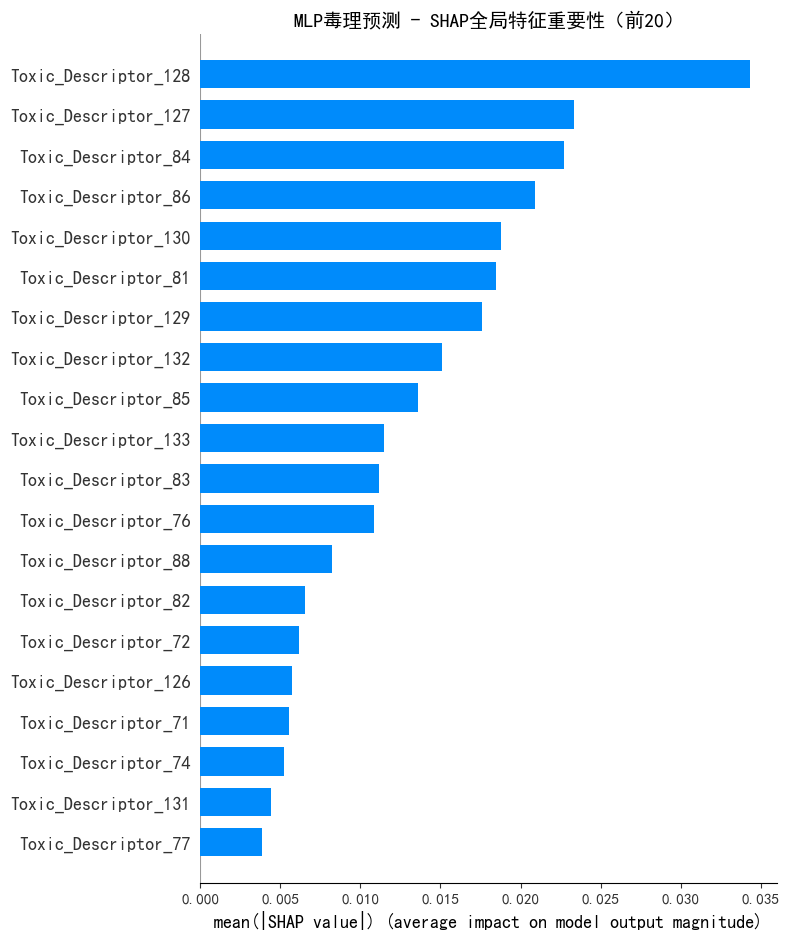

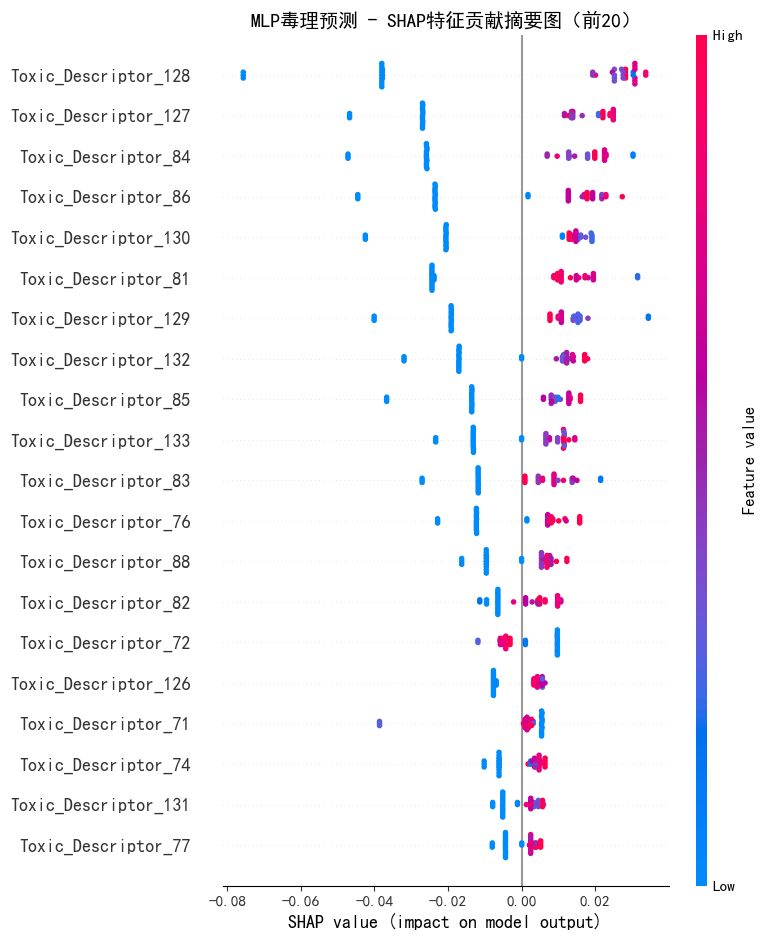


===== SHAP特征重要性排名（前20） =====
              Feature_Name  SHAP_Importance
1152  Toxic_Descriptor_128         0.034296
1151  Toxic_Descriptor_127         0.023337
1108   Toxic_Descriptor_84         0.022728
1110   Toxic_Descriptor_86         0.020916
1154  Toxic_Descriptor_130         0.018787
1105   Toxic_Descriptor_81         0.018488
1153  Toxic_Descriptor_129         0.017572
1156  Toxic_Descriptor_132         0.015111
1109   Toxic_Descriptor_85         0.013627
1157  Toxic_Descriptor_133         0.011464
1107   Toxic_Descriptor_83         0.011169
1100   Toxic_Descriptor_76         0.010863
1112   Toxic_Descriptor_88         0.008262
1106   Toxic_Descriptor_82         0.006545
1096   Toxic_Descriptor_72         0.006160
1150  Toxic_Descriptor_126         0.005725
1095   Toxic_Descriptor_71         0.005517
1098   Toxic_Descriptor_74         0.005244
1155  Toxic_Descriptor_131         0.004408
1101   Toxic_Descriptor_77         0.003850

===== 物种特征重要性 =====
     Feature_Name  SHAP_I

In [10]:
# 步骤7：SHAP特征重要性分析（核心）
    # ------------------------------
print("\n📊 开始SHAP特征重要性分析...")
# 使用测试集数据进行SHAP分析（也可用训练集）
shap_compound_features = compound_test
shap_species_ids = species_test
importance_df = shap_analysis_wrapper(
    model, shap_compound_features, shap_species_ids, species2id, device
)

# ------------------------------

In [20]:
# SHAP特征重要性结果解析
 
# 1. 初始化mordred计算器（与你的代码完全一致：仅2D描述符）
calc = Calculator(descriptors, ignore_3D=True)

# 2. 获取所有2D描述符的列表（顺序与你的代码中生成的desc_array完全一致）
desc_list = list(calc.descriptors)

# 3. 生成「索引-名称-含义」映射表
desc_info = []
for idx, desc in enumerate(desc_list):
    # 描述符名称（如"LogP"）
    desc_name = desc.__class__.__name__
    # 描述符所属类别（如"Topological"）
    desc_category = desc.__module__.split(".")[-1]
    # 描述符简要说明（部分有官方文档链接）
    desc_doc = desc.__doc__.split("\n")[0] if desc.__doc__ else "无说明"
    
    desc_info.append({
        "Index": idx,          # 对应你的Toxic_Descriptor_{idx}
        "Name": desc_name,     # 描述符名称
        "Category": desc_category,  # 描述符类别
        "Description": desc_doc     # 描述符含义
    })

# 4. 转为DataFrame并保存（便于查询）
import pandas as pd
desc_df = pd.DataFrame(desc_info)
desc_df.to_csv("mordred_descriptor_mapping.csv", index=False, encoding="utf-8")

# 5. 直接查询Toxic_Descriptor_129对应的信息
target_idx = 129
target_desc = desc_df[desc_df["Index"] == target_idx]
print(f"\n===== Toxic_Descriptor_{target_idx} 详细信息 =====")
print(f"名称：{target_desc['Name'].values[0]}")
print(f"类别：{target_desc['Category'].values[0]}")
print(f"含义：{target_desc['Description'].values[0]}")

# 可选：查询前20个重要描述符的含义
top_desc_indices = [129, 130, 80, 74, 127, 75, 128, 292, 72, 125, 83, 131, 283, 280, 73, 82, 84, 290, 278, 132]
top_desc_info = desc_df[desc_df["Index"].isin(top_desc_indices)]
print("\n===== 前20个重要描述符的含义 =====")
print(top_desc_info[["Index", "Name", "Category", "Description"]])


===== Toxic_Descriptor_129 详细信息 =====
名称：ATS
类别：Autocorrelation
含义：Autocorrelation of Topological Structure descriptor.

===== 前20个重要描述符的含义 =====
     Index  Name         Category  \
72      72   ATS  Autocorrelation   
73      73   ATS  Autocorrelation   
74      74   ATS  Autocorrelation   
75      75   ATS  Autocorrelation   
80      80   ATS  Autocorrelation   
82      82   ATS  Autocorrelation   
83      83   ATS  Autocorrelation   
84      84   ATS  Autocorrelation   
125    125   ATS  Autocorrelation   
127    127   ATS  Autocorrelation   
128    128   ATS  Autocorrelation   
129    129   ATS  Autocorrelation   
130    130   ATS  Autocorrelation   
131    131   ATS  Autocorrelation   
132    132   ATS  Autocorrelation   
278    278  ATSC  Autocorrelation   
280    280  ATSC  Autocorrelation   
283    283  ATSC  Autocorrelation   
290    290  ATSC  Autocorrelation   
292    292  ATSC  Autocorrelation   

                                           Description  
72   Autocorrelati

In [11]:
# 步骤8：批量预测
def batch_predict_excel(
    model,
    input_excel_path,  # 输入Excel路径
    output_excel_path="AO1065Prob.xlsx",  # 输出Excel路径
    species2id=None,  # 物种映射字典
    smiles_col="smiles",  # Excel中SMILES列名
    species_col="species",  # Excel中物种列名
    device="cpu"
):
    """
    批量预测Excel中的化合物毒性概率
    参数说明：
    - model: 训练好的模型
    - input_excel_path: 输入Excel文件路径（包含SMILES和物种列）
    - output_excel_path: 输出Excel文件路径（默认AO1065Prob.xlsx）
    - species2id: 物种映射字典（必须与训练时一致）
    - smiles_col: Excel中SMILES列的名称
    - species_col: Excel中物种列的名称
    - device: 运行设备
    """
    # 校验物种映射字典
    if species2id is None or not isinstance(species2id, dict):
        raise ValueError("必须提供有效的species2id字典（与训练时一致）")
    
    # 1. 读取Excel文件
    try:
        df = pd.read_excel(input_excel_path, engine="openpyxl")
        print(f"✅ 成功读取Excel文件，共{len(df)}条数据")
    except FileNotFoundError:
        raise FileNotFoundError(f"❌ 未找到输入Excel文件：{input_excel_path}")
    except Exception as e:
        raise Exception(f"❌ 读取Excel失败：{str(e)}")
    
    # 2. 校验必要列
    required_cols = [smiles_col, species_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"❌ Excel缺少必要列：{missing_cols}，请检查列名是否正确")
    
    # 3. 批量预测（带进度提示）
    print("\n🚀 开始批量预测毒性概率...")
    toxicity_probs = []
    toxicity_labels = []  # 毒性判定（有毒/无毒）
    error_indices = []    # 记录预测失败的行号
    
    for idx, row in df.iterrows():
        try:
            # 获取SMILES和物种（去除首尾空格）
            smiles = str(row[smiles_col]).strip()
            species = str(row[species_col]).strip()
            
            # 跳过空值
            if smiles == "nan" or len(smiles) == 0:
                toxicity_probs.append(np.nan)
                toxicity_labels.append("无效SMILES")
                continue
            if species == "nan" or len(species) == 0:
                toxicity_probs.append(np.nan)
                toxicity_labels.append("无效物种")
                continue
            
            # 调用预测函数
            prob = predict_toxicity(
                model=model,
                smiles=smiles,
                species=species,
                species2id=species2id,
                device=device
            )
            
            toxicity_probs.append(prob)
            # 毒性判定（阈值0.5，可根据需求调整）
            toxicity_labels.append("有毒" if prob >= 0.5 else "无毒")
            
            # 每预测50条打印进度
            if (idx + 1) % 50 == 0:
                print(f"进度：{idx + 1}/{len(df)} 条数据已预测")
        
        except Exception as e:
            print(f"⚠️ 第{idx + 1}行数据预测失败：{str(e)}")
            toxicity_probs.append(np.nan)
            toxicity_labels.append("预测失败")
            error_indices.append(idx)
    
    # 4. 将预测结果添加到DataFrame
    df["生殖毒性概率"] = toxicity_probs
    df["毒性判定"] = toxicity_labels
    
    # 5. 保存新Excel文件
    try:
        df.to_excel(output_excel_path, index=False, engine="openpyxl")
        print(f"\n✅ 预测完成！结果已保存至：{output_excel_path}")
    except Exception as e:
        raise Exception(f"❌ 保存Excel失败：{str(e)}")
    
    # 6. 打印预测统计信息
    print("\n📊 预测结果统计：")
    print(f"总数据条数：{len(df)}")
    print(f"有效预测条数：{len([p for p in toxicity_probs if not np.isnan(p)])}")
    print(f"无效预测条数：{len([p for p in toxicity_probs if np.isnan(p)])}")
    print(f"有毒化合物数：{len([l for l in toxicity_labels if l == '有毒'])}")
    print(f"无毒化合物数：{len([l for l in toxicity_labels if l == '无毒'])}")
    if error_indices:
        print(f"预测失败行号：{[i+1 for i in error_indices]}")
    
    # 7. 显示前5条结果预览
    print("\n🔍 前5条预测结果预览：")
    preview_cols = [smiles_col, species_col, "生殖毒性概率", "毒性判定"]
    print(df[preview_cols].head())

In [12]:
# -------------------------- 执行批量预测 --------------------------
input_excel_path = "AO1065chemicalsmiles.xlsx"  # 你的输入Excel路径
output_excel_path = "AO1065Prob.xlsx"  # 输出Excel名称（固定为AO1065Prob）

batch_predict_excel(
    model=model,
    input_excel_path=input_excel_path,
    output_excel_path=output_excel_path,
    species2id=species2id,
    smiles_col="smiles", 
    species_col="species",  
    device=device
)

✅ 成功读取Excel文件，共4282条数据

🚀 开始批量预测毒性概率...
进度：50/4282 条数据已预测
进度：100/4282 条数据已预测
进度：150/4282 条数据已预测
进度：200/4282 条数据已预测
进度：250/4282 条数据已预测
进度：300/4282 条数据已预测
进度：350/4282 条数据已预测
进度：400/4282 条数据已预测
进度：450/4282 条数据已预测
进度：500/4282 条数据已预测
进度：550/4282 条数据已预测
进度：600/4282 条数据已预测
进度：650/4282 条数据已预测
进度：700/4282 条数据已预测
进度：750/4282 条数据已预测
进度：800/4282 条数据已预测
进度：850/4282 条数据已预测
进度：900/4282 条数据已预测
进度：950/4282 条数据已预测
进度：1000/4282 条数据已预测
进度：1050/4282 条数据已预测
进度：1100/4282 条数据已预测
进度：1150/4282 条数据已预测
进度：1200/4282 条数据已预测
进度：1250/4282 条数据已预测
进度：1300/4282 条数据已预测
进度：1350/4282 条数据已预测
进度：1400/4282 条数据已预测
进度：1450/4282 条数据已预测
进度：1500/4282 条数据已预测
进度：1550/4282 条数据已预测
进度：1600/4282 条数据已预测
进度：1650/4282 条数据已预测
进度：1700/4282 条数据已预测
进度：1750/4282 条数据已预测
进度：1800/4282 条数据已预测
进度：1850/4282 条数据已预测
进度：1900/4282 条数据已预测
进度：1950/4282 条数据已预测
进度：2000/4282 条数据已预测
进度：2050/4282 条数据已预测
进度：2100/4282 条数据已预测
进度：2150/4282 条数据已预测
进度：2200/4282 条数据已预测
进度：2250/4282 条数据已预测
进度：2300/4282 条数据已预测
进度：2350/4282 条数据已预测
进度：2400/4282 条数据已预测
进度：2450/4282 条数据已预测
